In [1]:
!git clone https://github.com/apt2736/PKM_RF.git

Cloning into 'PKM_RF'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 30 (delta 7), reused 17 (delta 7), pack-reused 11 (from 1)
Receiving objects: 100% (30/30), 95.72 MiB | 28.00 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [1]:
%cd PKM_RF

!git fetch --all
!git reset --hard origin/master

/content/PKM_RF
Fetching origin
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 5 (delta 2), reused 5 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 454.02 KiB | 6.78 MiB/s, done.
From https://github.com/apt2736/PKM_RF
   60e20f7..be119b4  master     -> origin/master
HEAD is now at be119b4 fix: mem optimization on plot_utils.ipynb


In [2]:
%run setup.ipynb

===> Checking R installation...
R is already installed:
Rscript (R) version 4.6.0 (2026-04-24)
===> Ensuring Python rpy2 is installed...
===> Installing R prebuilt binary packages via APT...
Reading package lists...
Building dependency tree...
Reading state information...
r-cran-caret is already the newest version (7.0-1-1.ca2204.1).
r-cran-data.table is already the newest version (1.18.4-1.ca2204.1).
r-cran-dplyr is already the newest version (1.2.1-1.ca2204.1).
r-cran-e1071 is already the newest version (1.7-17-1.ca2204.1).
r-cran-jsonlite is already the newest version (2.0.0-1.ca2204.1).
r-cran-lightgbm is already the newest version (4.7.0-1.ca2204.1).
r-cran-nnet is already the newest version (7.3-21-1.ca2204.1).
r-cran-proc is already the newest version (1.19.0.1-1.ca2204.1).
r-cran-randomforest is already the newest version (4.7-1.2-1.ca2204.1).
r-cran-ranger is already the newest version (0.18.0-1.ca2204.1).
r-cran-xgboost is already the newest version (3.2.1.1-1.ca2204.1).
r-cr

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


All required R packages are already installed!
Registering IRkernel for Jupyter notebook...
===> Verification Report:
R Version: R version 4.6.0 (2026-04-24) 

Package            Status      
------------------------------ 
randomForest       [OK]        
ranger             [OK]        
caret              [OK]        
e1071              [OK]        
nnet               [OK]        
jsonlite           [OK]        
dplyr              [OK]        
ggplot2            [OK]        
pROC               [OK]        
data.table         [OK]        
xgboost            [OK]        
lightgbm           [OK]        
IRkernel           [OK]        
girdExtra          [MISSING]   
------------------------------ 
NOTE: Some optional packages are missing. Re-run setup if needed.


=== Configuration Loaded ===
Data Source Path: datasets/5v_cleandf.RData 
Target Column:    esi 
Features Count:   18 



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Loading dataset from: datasets/5v_cleandf.RData ...
Loaded dataset: 560486 rows x 19 cols (Features in JSON: 18)
=== ESI Target Class Summary ===
# A tibble: 6 × 3
  esi    Count Percentage
  <fct>  <int>      <dbl>
1 1       5271      0.940
2 2     163534     29.2  
3 3     236229     42.1  
4 4     125003     22.3  
5 5      27992      4.99 
6 <NA>    2457      0.438


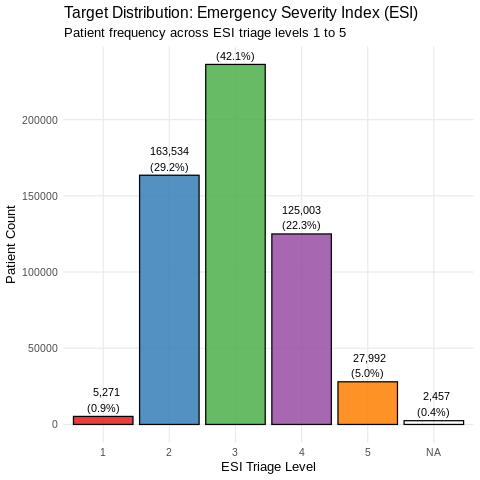

Plotting distributions for base features in config: age, triage_vital_hr, triage_vital_sbp, triage_vital_rr, triage_vital_o2, pulse_last, resp_last, spo2_last, sbp_last, pulse_min, resp_min, spo2_min, sbp_min, pulse_max, resp_max, spo2_max, sbp_max 


In addition: Warning messages:
1: Removed 63130 rows containing non-finite outside the scale range
(`stat_density()`). 
2: Removed 63130 rows containing non-finite outside the scale range
(`stat_density()`). 
3: Removed 63130 rows containing non-finite outside the scale range
(`stat_boxplot()`). 
4: Removed 63130 rows containing non-finite outside the scale range
(`stat_boxplot()`). 


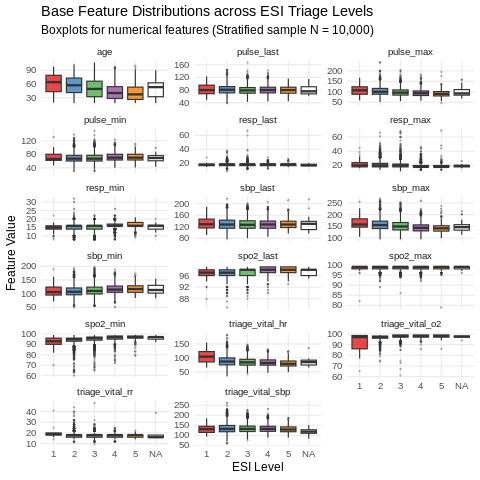

=== Computing Engineered Clinical Features from TODO.md ===


In [ ]:
%run plots/plot_utils.ipynb

In [9]:
%run models/lr_extreme.ipynb

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
=== Configuration Loaded from config/triage_conf.json ===
Data Source Path: datasets/5v_cleandf.RData 
Target Column:    esi 
Features Count:   6 
Test Size:        0.15 
Val Size:         0.15 
Random State:     42 


Loading required package: lattice
Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var

In addition: Warning message:
package ‘nnet’ was built under R version 4.6.1 


Loading dataset from: datasets/5v_cleandf.RData ...
Selected main complete dataset object: 'df' (560486 rows)
Target Column:    esi 
Features from JSON (6): age, gender, triage_vital_hr, triage_vital_o2, pulse_last, spo2_last
Layer 1 Dataset Ready: 127795 rows x 8 cols
Layer 1 Target Distribution (Complete Dataset):

      1       5 neither 
    188    5688  121919 
Partition sizes:
  Train: 89458 rows
  Val:   19169 rows
  Test:  19168 rows
Training Layer 1 Multinomial Logistic Regressor on complete dataset...
Layer 1 Logistic Regression training complete!
Call:
multinom(formula = formula_lr, data = train_df, trace = FALSE, 
    MaxNWts = 5000)

Coefficients:
        (Intercept)        age      gender triage_vital_hr triage_vital_o2
5          3.747076 -1.1698520 -0.09860101      -0.9840908       0.5013758
neither    7.026314 -0.7134591 -0.20546923      -0.5571885       0.2628620
        pulse_last     spo2_last
5       0.07571101  0.1151381715
neither 0.04319108 -0.0002164652

Std. E

In [10]:
%run models/rf_extreme.ipynb

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
=== Configuration Loaded from config/triage_conf.json ===
Data Source Path: datasets/5v_cleandf.RData 
Target Column:    esi 
Features Count:   6 
Test Size:        0.15 
Val Size:         0.15 
Random State:     42 


ranger 0.18.0 using 2 threads (default). Change with num.threads in ranger() and predict(), options(Ncpus = N), options(ranger.num.threads = N) or environment variable R_RANGER_NUM_THREADS.


Loading dataset from: datasets/5v_cleandf.RData ...
Selected main dataset object: 'df' (560486 rows)
Target Column:    esi 
Features from JSON (6): age, gender, triage_vital_hr, triage_vital_o2, pulse_last, spo2_last
Layer 2 Filtered Dataset Ready (No ESI 1 & 5): 121919 rows x 7 cols
Layer 2 Target Distribution:

    2     3     4 
38590 54322 29007 
Layer 2 Partitions:
  Train: 85345 rows
  Val:   18287 rows
  Test:  18287 rows
Training Layer 2 Random Forest on ESI 2, 3, 4 data...
Growing trees.. Progress: 80%. Estimated remaining time: 7 seconds.
Layer 2 Random Forest training complete!
Ranger result

Call:
 ranger(formula = formula_rf, data = train_df_l2, num.trees = 300,      importance = "impurity", probability = TRUE, seed = config$training$random_state) 

Type:                             Probability estimation 
Number of trees:                  300 
Sample size:                      85345 
Number of independent variables:  6 
Mtry:                             2 
Target node siz